In [2]:
!nvidia-smi

Tue Jul  7 00:10:37 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   57C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 63.2 MB/s eta 0:00:00


In [1]:
import ultralytics
ultralytics.checks()

Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.0/112.6 GB disk)


In [2]:
from ultralytics import YOLO
from IPython.display import Image

model = YOLO("yolo26n-seg.pt")

In [3]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="trta6GNa9BxIphg4DPfG")
project = rf.workspace("abdullahs-workspace-rcwes").project("plant-disease-ypxen-ostae")
version = project.version(1)
dataset = version.download("yolo26")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Plant-disease-1 in yolo26:: 100%|██████████| 3716/3716 [00:00<00:00, 5545.98it/s]


In [6]:
train_result = model.train(
    data = '/content/Plant-disease-1',
            epochs = 40,
            imgsz = 640 )

Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Plant-disease-1, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=40, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=10

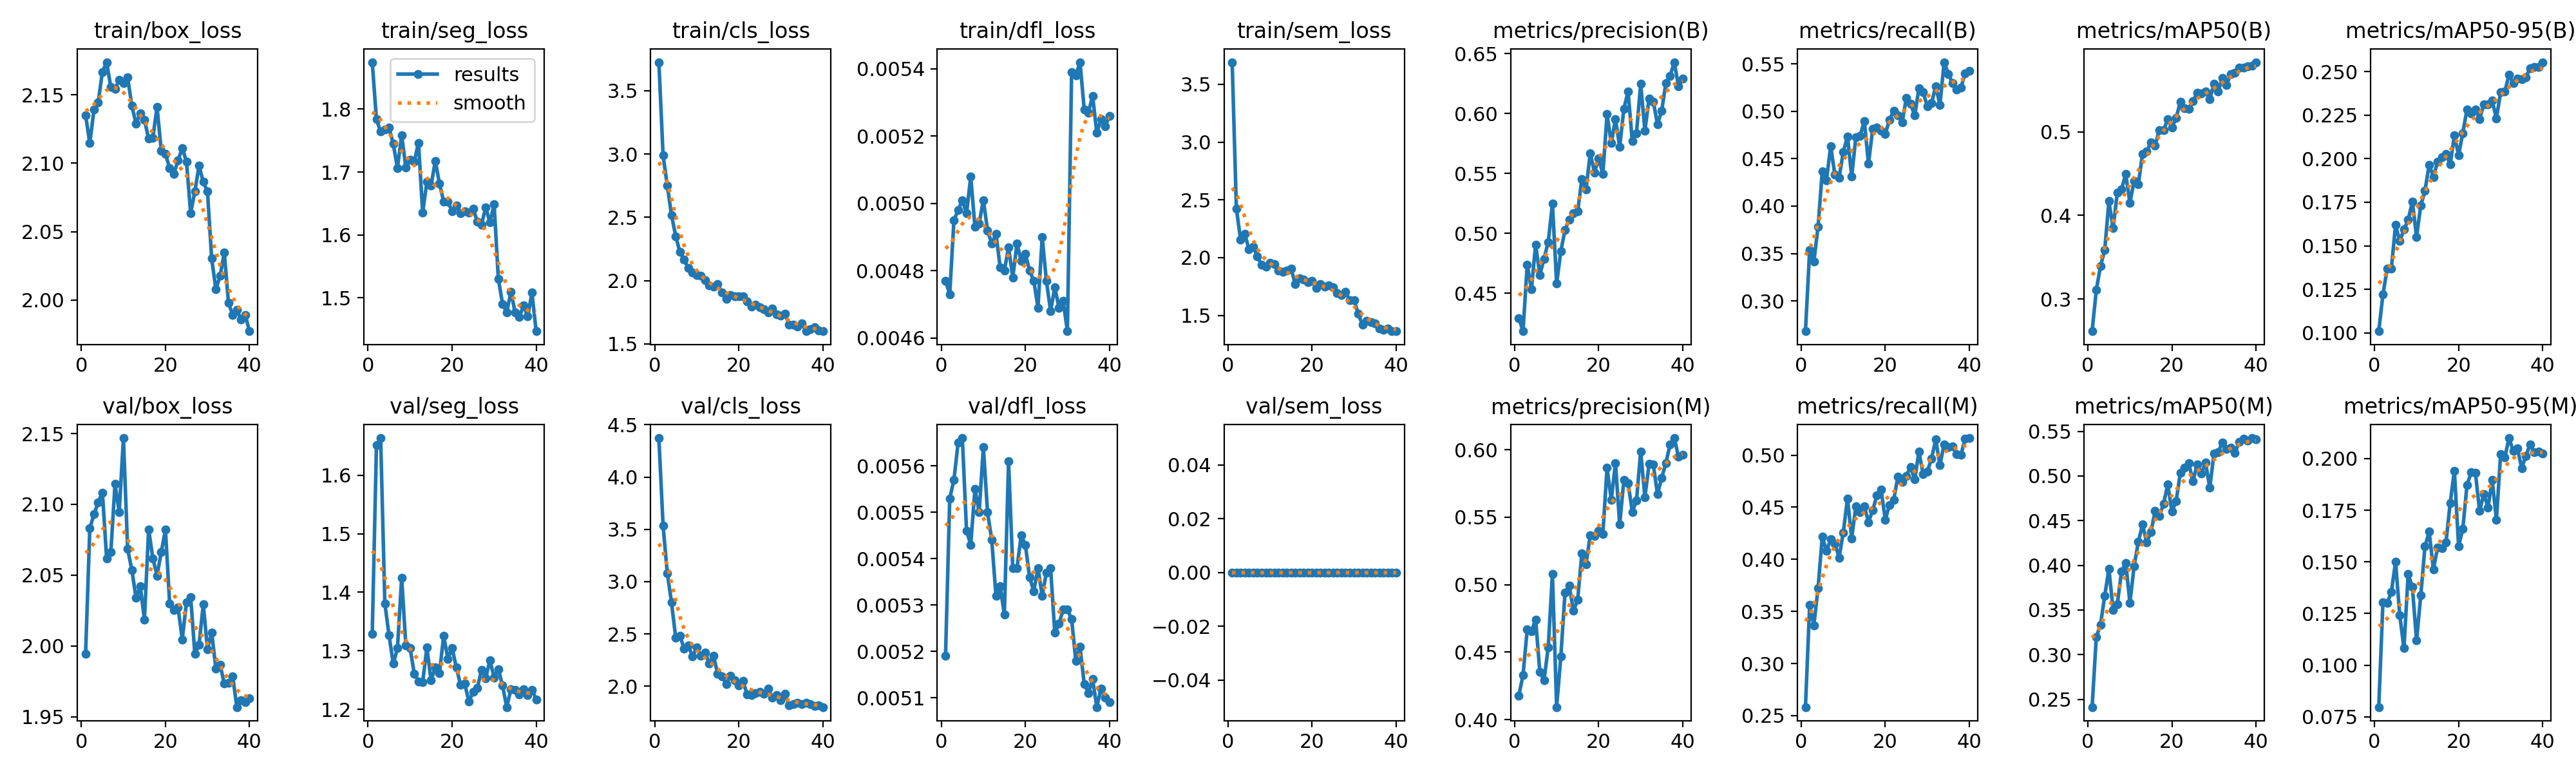

In [8]:
Image("/content/runs/segment/train-3/results.png", width=600)

# Inference


image 1/1 /content/Plant-disease-1/test/images/V006_77_1_02_01_05_13_2_1006w_20201119_96_jpg.rf.38433dc2db673981bb699f013f2d7b2a.jpg: 640x640 (no detections), 25.7ms
Speed: 5.5ms preprocess, 25.7ms inference, 0.4ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/segment/predict-5


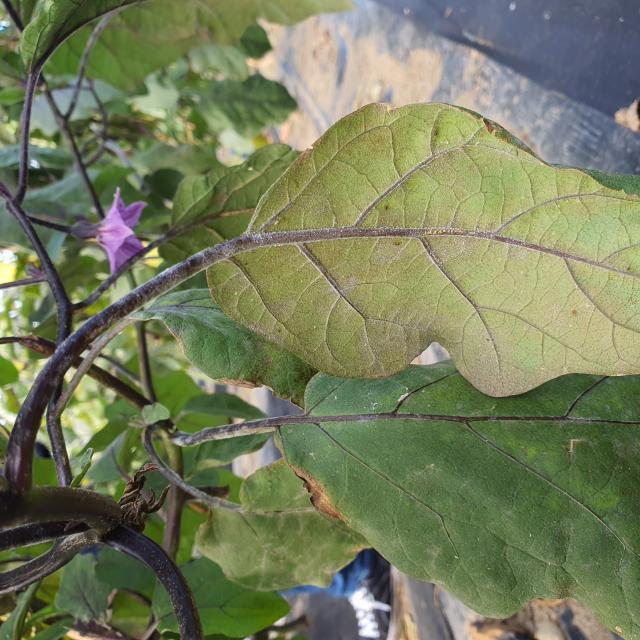

In [13]:
model = YOLO("/content/runs/segment/train-3/weights/best.pt")
results = model("/content/Plant-disease-1/test/images/V006_77_1_02_01_05_13_2_1006w_20201119_96_jpg.rf.38433dc2db673981bb699f013f2d7b2a.jpg", save = True)
results[0].show()